In [29]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

import matplotlib

STATS_DIR = "/mnt/d/cyclistic-bike-share/outputs/summary_stats"
CHARTS_DIR = "/mnt/d/cyclistic-bike-share/outputs/charts"

os.makedirs(CHARTS_DIR, exist_ok=True)

MEMBER_COLOR = "#1F4E78"
CASUAL_COLOR = "#1D9E75"

plt.style.use('default')
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 14,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

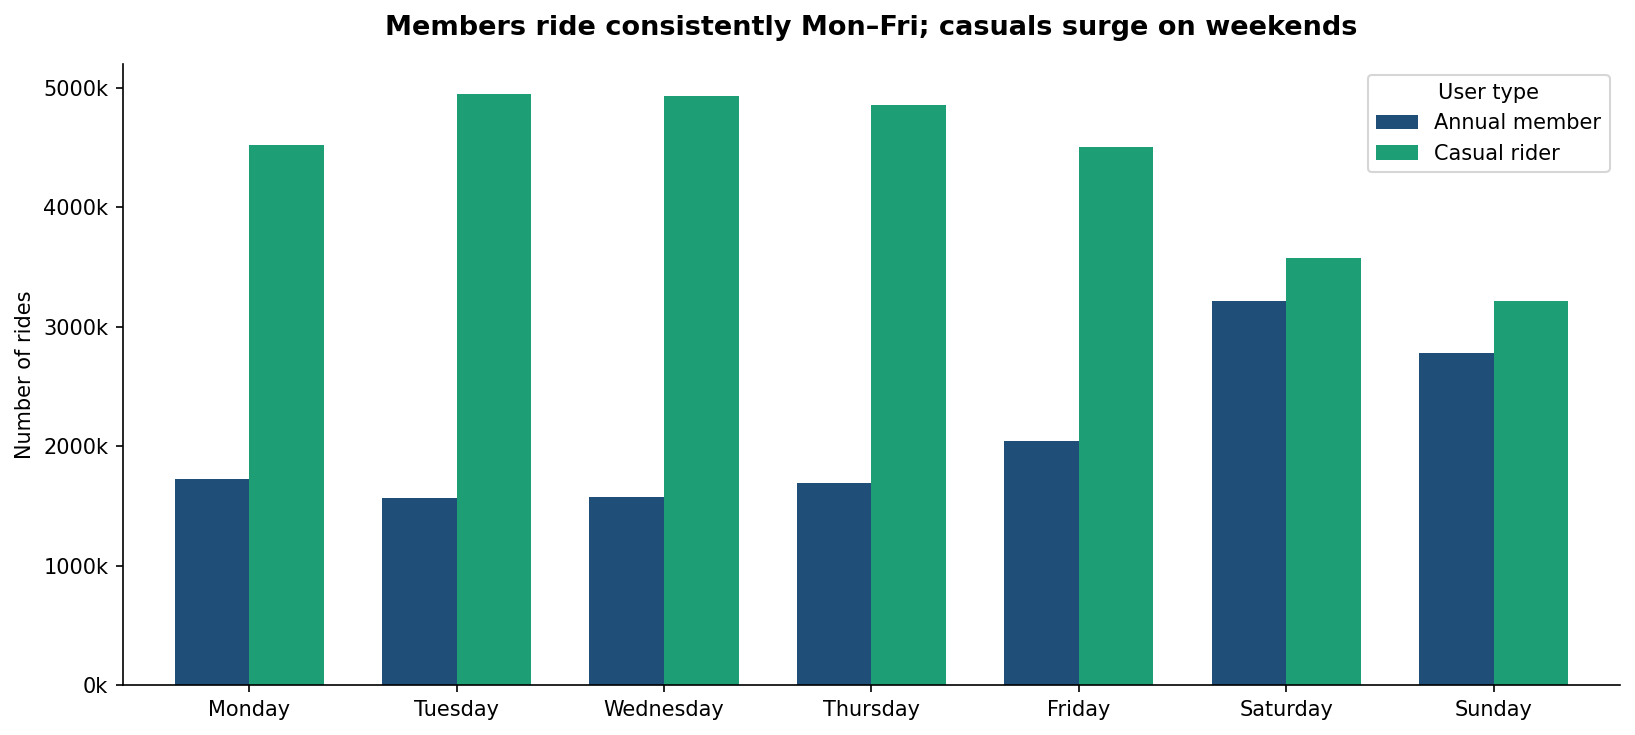

In [31]:
# Chart 1: Rides per day

df1 = pd.read_csv(f"{STATS_DIR}/01_rides_by_day.csv")
df1["day_of_week"] = pd.Categorical(df1["day_of_week"], categories=DAY_ORDER, ordered=True)
df1 = df1.sort_values("day_of_week")

pivot1 = df1.pivot(index="day_of_week", columns="member_casual", values="ride_count")

fig, ax = plt.subplots(figsize=(11, 5))
pivot1.plot(kind="bar", ax=ax, color=[MEMBER_COLOR, CASUAL_COLOR], width=0.72, edgecolor="none")

ax.set_title("Members ride consistently Mon–Fri; casuals surge on weekends")
ax.set_xlabel("")
ax.set_ylabel("Number of rides")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend(["Annual member", "Casual rider"], title="User type")

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/01_rides_by_day.png", bbox_inches="tight")
plt.show()
plt.close()

Chart 2 saved.


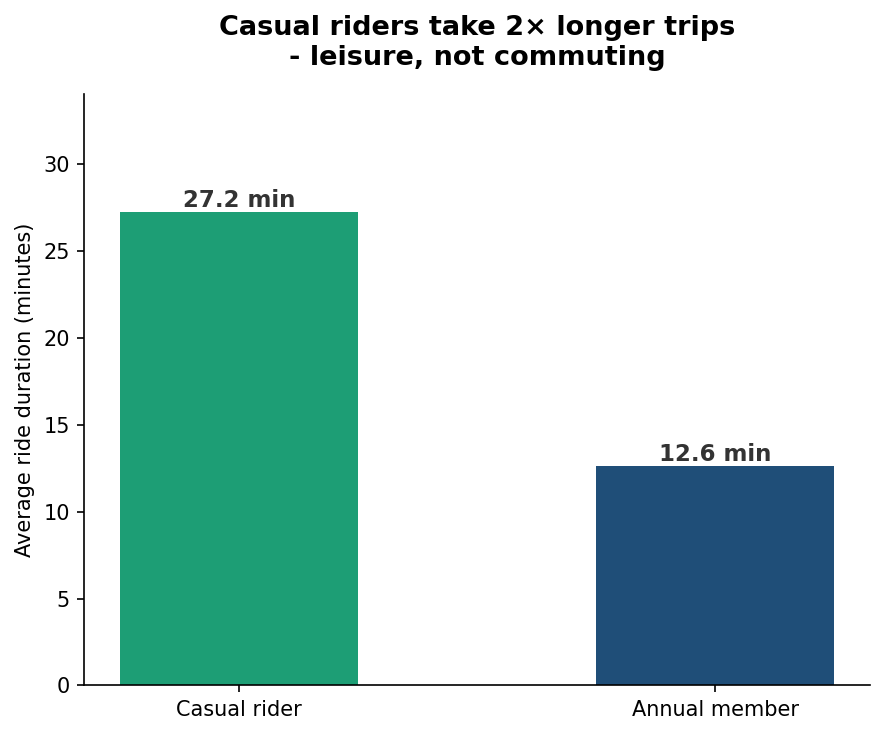

In [38]:
# Chart 2: Average duration

df2 = pd.read_csv(f"{STATS_DIR}/02_avg_duration.csv")

fig, ax = plt.subplots(figsize=(6, 5))
bar_colors = [PALETTE.get(r["member_casual"], "#888888") for _, r in df2.iterrows()]
bars = ax.bar(df2["member_casual"], df2["avg_duration_min"],
              color=bar_colors, width=0.5, edgecolor="none")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f} min',
            ha="center", fontsize=11, fontweight="bold", color="#333")

ax.set_title("Casual riders take 2× longer trips\n- leisure, not commuting")
ax.set_ylabel("Average ride duration (minutes)")

ax.set_xticks(range(len(df2["member_casual"])))
ax.set_xticklabels(["Casual rider", "Annual member"])
ax.set_ylim(0, df2["avg_duration_min"].max() * 1.25)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_avg_duration.png", bbox_inches="tight")
print("Chart 2 saved.")

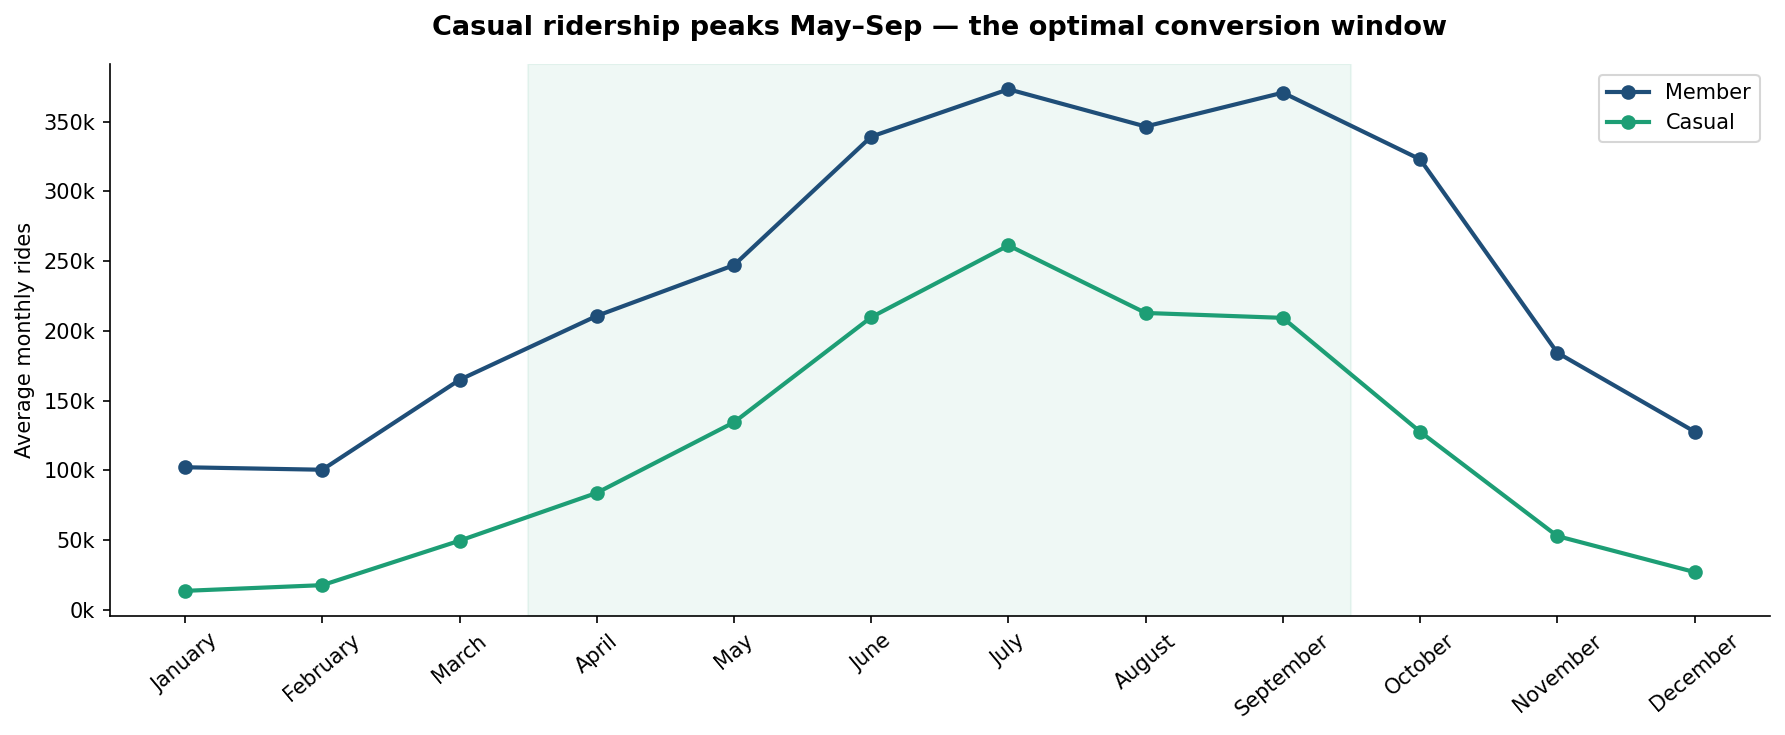

In [34]:
# Chart 3: Monthly seasonality

df3 = pd.read_csv(f"{STATS_DIR}/03_monthly_rides.csv")

df3_avg = (df3
    .groupby(["member_casual", "month_num", "month"])["ride_count"]
    .mean()
    .reset_index()
    .sort_values("month_num")
)

fig, ax = plt.subplots(figsize=(12, 5))

for user_type, color in [("member", MEMBER_COLOR), ("casual", CASUAL_COLOR)]:
    data = df3_avg[df3_avg["member_casual"] == user_type]
    ax.plot(data["month"], data["ride_count"],
            marker="o", color=color, linewidth=2, label=user_type.title())

month_labels = df3_avg["month"].drop_duplicates().tolist()
if len(month_labels) == 12:
    ax.axvspan(2.5, 8.5, alpha=0.07, color=CASUAL_COLOR)

ax.set_title("Casual ridership peaks May–Sep — the optimal conversion window")
ax.set_xlabel("")
ax.set_ylabel("Average monthly rides")
ax.tick_params(axis="x", rotation=40)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/03_monthly_trends.png", bbox_inches="tight")
plt.show()
plt.close()

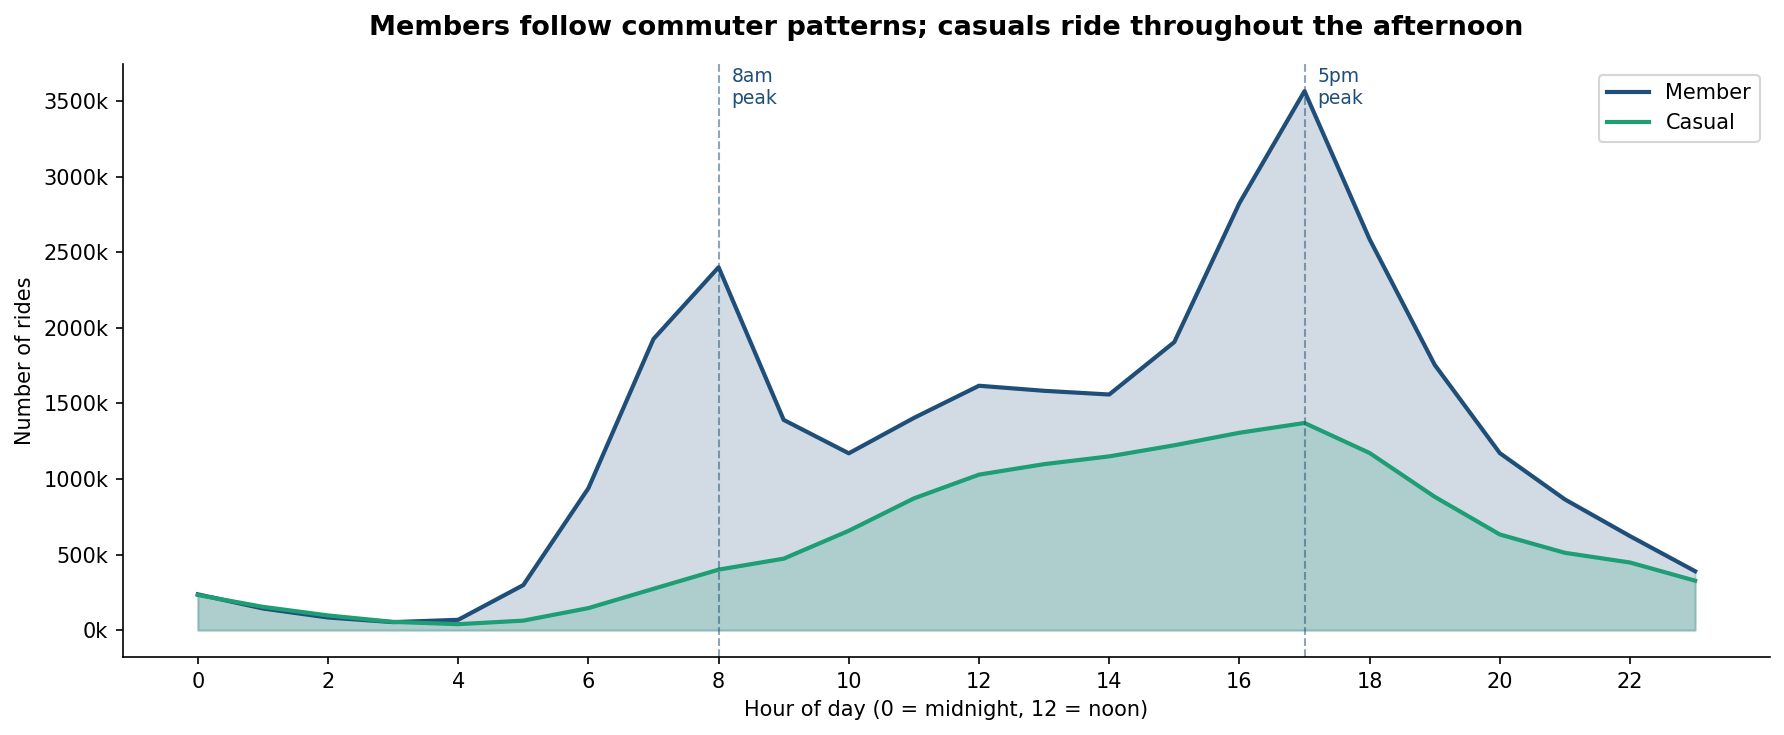

In [35]:
# Chart 4: Hour-of-day

df4 = pd.read_csv(f"{STATS_DIR}/04_peak_hours.csv")

fig, ax = plt.subplots(figsize=(12, 5))

for user_type, color in [("member", MEMBER_COLOR), ("casual", CASUAL_COLOR)]:
    data = df4[df4["member_casual"] == user_type].sort_values("hour")
    ax.fill_between(data["hour"], data["ride_count"], alpha=0.2, color=color)
    ax.plot(data["hour"], data["ride_count"],
            color=color, linewidth=2, label=user_type.title())

ax.axvline(x=8, color=MEMBER_COLOR, linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(x=17, color=MEMBER_COLOR, linestyle="--", alpha=0.5, linewidth=1)
ylim = ax.get_ylim()[1]
ax.text(8.2, ylim * 0.93, "8am\npeak", fontsize=9, color=MEMBER_COLOR, ha='left')
ax.text(17.2, ylim * 0.93, "5pm\npeak", fontsize=9, color=MEMBER_COLOR, ha='left')

ax.set_title("Members follow commuter patterns; casuals ride throughout the afternoon")
ax.set_xlabel("Hour of day (0 = midnight, 12 = noon)")
ax.set_ylabel("Number of rides")
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_peak_hours.png", bbox_inches="tight")
plt.show()
plt.close()

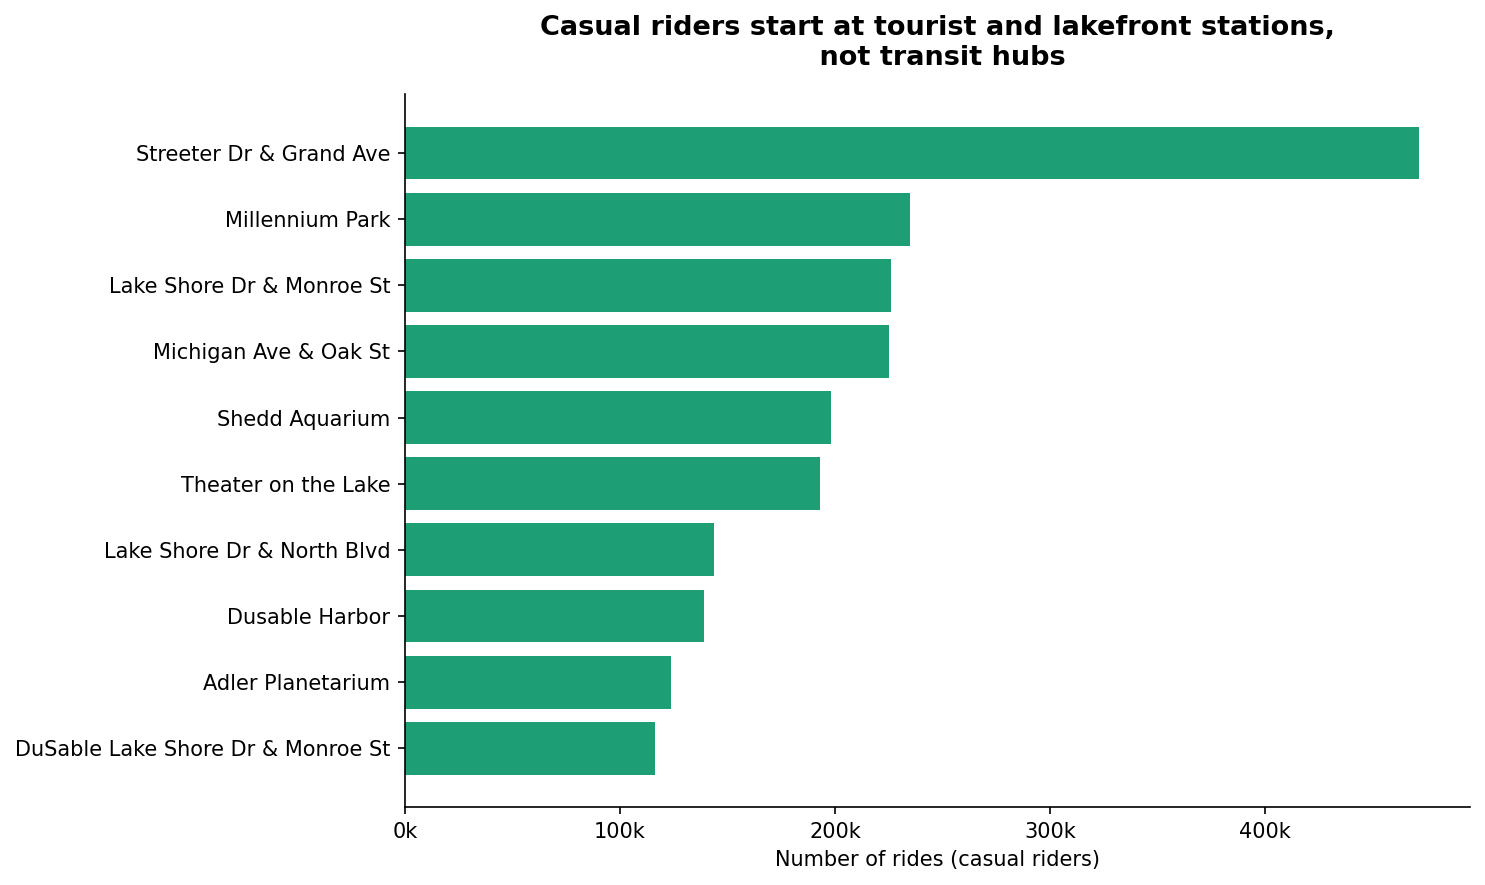

In [40]:
# Chart 5: Top casual stations

df5 = pd.read_csv(f"{STATS_DIR}/05_top_stations.csv")
casual_top = (df5[df5["member_casual"] == "casual"]
              .nlargest(10, "ride_count")
              .sort_values("ride_count"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(casual_top["start_station_name"], casual_top["ride_count"],
        color=CASUAL_COLOR, edgecolor="none")

ax.set_title("Casual riders start at tourist and lakefront stations,\n not transit hubs")
ax.set_xlabel("Number of rides (casual riders)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_top_casual_stations.png", bbox_inches="tight")
plt.show()
plt.close()

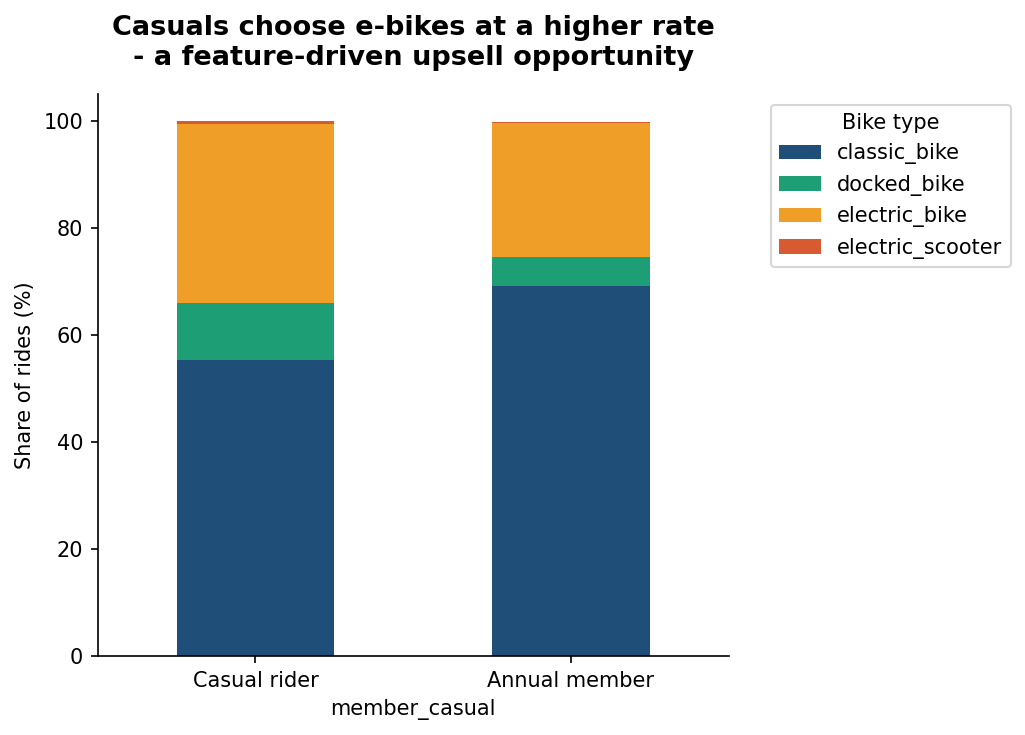

In [39]:
# Chart 6: Bike type preference (2020+ only)

df6 = pd.read_csv(f"{STATS_DIR}/06_bike_type.csv")

if df6.empty:
    print("⏭️ SKIPPED (no rideable_type data)")
else:
    pct = df6.copy()
    pct["pct"] = pct.groupby("member_casual")["ride_count"].transform(
        lambda x: (x / x.sum() * 100).round(1))
    pivot6 = pct.pivot(index="member_casual", columns="rideable_type", values="pct").fillna(0)

    fig, ax = plt.subplots(figsize=(7, 5))
    bike_colors = ["#1F4E79", "#1D9E75", "#EF9F27", "#D85A30", "#888888"][:len(pivot6.columns)]
    pivot6.plot(kind="bar", stacked=True, ax=ax,
                color=bike_colors, edgecolor="none", width=0.5)

    ax.set_title("Casuals choose e-bikes at a higher rate\n- a feature-driven upsell opportunity")
    ax.set_ylabel("Share of rides (%)")
    ax.set_xticklabels(["Casual rider", "Annual member"], rotation=0)
    ax.legend(title="Bike type", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(f"{CHARTS_DIR}/06_bike_type.png", bbox_inches="tight")
    plt.show()
    plt.close()